---
title: "Exercise 6: FLAMES Gene Prioritisation"
subtitle: "Post-GWAS Analysis Course"
format:
  html:
    embed-resources: true
    toc: true
    toc-depth: 3
execute:
  message: false
  warning: false
jupyter: ir
---

# Overview

This notebook introduces FLAMES, which prioritises candidate effector genes for a fine-mapped locus by combining several kinds of SNP-to-gene evidence with gene-level scores.

::: {.callout-note}
## Learning goals
By the end of this notebook, you should be able to:
- assemble the inputs FLAMES needs for a locus-specific run
- interpret the FLAMES ranking and score threshold
- explain what the top-ranked gene is supported by.
:::

In [1]:
out_dir <- "output/fm_out/"
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

library(data.table)
library(ggplot2)

# Credible set you exported at the end of Exercise 1 (Block 4)
cs_file <- file.path(out_dir, "credible_sets_for_flames.tsv")

## Overview

In Exercise 1 you fine-mapped the **ADHD SORCS3 locus** down to a credible set.
A credible set is a list of *variants*, FLAMES is aiming to connect them to *genes*.
**FLAMES** (*Schipper et al., Nat Genet 2025*) is an effector-gene prioritiser: it
takes a fine-mapped locus and scores each nearby gene by combining several
SNP-to-gene evidence (eQTL/chromatin links, distance, and functional
annotations) through an **XGBoost** classifier, then scales that by the gene-level
**PoPS** convergence score into one **scaled FLAMES score** per gene.

In this exercise you will:

1. Assemble the FLAMES inputs and run the two-steps commands
2. Apply the FLAMES score threshold and read the ranking
3. Trace *which* evidence drove the top call
4. Interpret what a confident FLAMES call means

---

## 1: Run FLAMES

Running FLAMES requires 2 calls.(`annotate` then `FLAMES`). Before that it requires
four inputs in addition to your credible set:

| Input | Flag | Where it comes from |
|-------|------|---------------------|
| Credible set (SNP + PIP) | `-c` | your Exercise 1 export |
| Annotation reference | `-a` | Zenodo 12635505 |
| PoPS gene scores (`.preds`) | `-p` | PoPS run on the ADHD MAGMA Z-scores |
| MAGMA gene Z (`.genes.out`) | `-m` | MAGMA gene analysis on ADHD |
| MAGMA tissue (`.gsa.out`) | `-mt` | MAGMA GTEx-v8 tissue analysis on ADHD |

::: callout-note
**FLAMES re-trims your credible set.**

`annotate` reduces whatever you give it to a 95% credible set, "the smallest number
of variants that together have a summed PIP of at least 0.95" (Schipper et al.,
Methods). The SORCS3 credible set with SuSiE set sums to 0.955, so the lowest-PIP variant is dropped and
FLAMES annotates 5 of the 6. You can check this in the `credset_size` column of the
annotated file. `-c95 False` keeps all of them, but the default is what the paper
does.
:::

::: callout-note
**Credible-set file format.** FLAMES reads a per-locus file whose SNP column is
`CHR:BP:A1:A2` (or `CHR:BP:A1_A2`) and a PIP column. Different finemapping tools will output their results in various formats. As such you always have to convert their output to the format FLAMES expects. Your Exercise 1 export
already has `SNP` and `PIP` columns, so you point FLAMES at them with `-sc SNP
-pc PIP`. 
:::

In [2]:
if (file.exists(cs_file)) {
  cs <- fread(cs_file)
  cat("Credible set file found:", nrow(cs), "SNPs\n")
  print(head(cs))
} else {
  message("credible_sets_for_flames.tsv not found, run Exercise 1 first.")
}

Credible set file found: 6 SNPs
                SNP        PIP      locus_id
             <char>      <num>        <char>
1: 10:106529451:T:C 0.01778466 locus1_SORCS3
2: 10:106533655:A:G 0.14598086 locus1_SORCS3
3: 10:106537886:T:C 0.20450403 locus1_SORCS3
4: 10:106541524:G:A 0.10479631 locus1_SORCS3
5: 10:106550944:A:G 0.21633340 locus1_SORCS3
6: 10:106559287:T:C 0.26531046 locus1_SORCS3


::: callout-note
**FLAMES needs reference data + genome-wide inputs.** The `-a` annotation
reference (~10 GB), and the MAGMA/PoPS files, are already produced beforehand from the full
ADHD summary statistics. The rest of this exercise uses the
**example SORCS3 output** so everyone has the same starting point.

Reference data: <https://zenodo.org/records/12635505>

Nothing in it depends on your GWAS. It is a fixed catalogue of published
SNP-to-gene and enhancer-to-gene links that FLAMES looks up. It does not derive
any of when you run it.
:::

Now we run the two FLAMES calls. The first **annotates** your credible-set SNPs
against the reference, then the second **scores** the genes. (Genome build is GRCh37,
the same build as the 1000G LD and sumstats in Exercise 1.)

In [3]:
# Step 1: annotate the credible-set SNPs against the reference.
# Fill in the four per-GWAS inputs from the table above.
to_run <- "
flames annotate -c output/fm_out/credible_sets_for_flames.tsv \\
-sc  SNP  -pc PIP \\
-a   ____ \\
-p   ____ \\
-m   ____ \\
-mt  ____ \\
-b   GRCh37 \\
-o   output/fm_out/flames_annot > output/fm_out/annotate.log 2>&1
"

status <- system(to_run)
cat("exit status:", status, "\n")
cat(readLines("output/fm_out/annotate.log"), sep = "\n")



exit status: 0 

*********************************************************************
*Fine-mapped Locus Assesment Model of Effector geneS (FLAMES)
* Version 1.1.2
* (C) 2023 Marijn Schipper
*********************************************************************

Starting_annotation:

[====================] 1/1 (100.0%) - Locus processed in: 18.68s
Runtime: 18.92


<details>
<summary><b>Solution</b> (click to expand)</summary>

```r
to_run <- "
flames annotate -c output/fm_out/credible_sets_for_flames.tsv \\
-sc  SNP  -pc PIP \\
-a   input/flames/Annotation_data \\
-p   input/flames/adhd_pops.preds \\
-m   input/flames/adhd.genes.out \\
-mt  input/flames/adhd_tissue.gsa.out \\
-b   GRCh37 \\
-o   output/fm_out/flames_annot > output/fm_out/annotate.log 2>&1
"
system(to_run)
```

</details>

In [4]:
# Step 2: score the annotated locus.
dir.create("output/fm_out/flames_out", showWarnings = FALSE, recursive = TRUE)

# `flames FLAMES -i` wants a file listing the annotated paths, one per line.
# annotate writes output/fm_out/flames_annot/FLAMES_annotated_<credset>.tsv
to_run <- "ls output/fm_out/flames_annot/FLAMES_annotated_*.tsv > output/fm_out/flames_annot.txt"
system(to_run)
cat(readLines("output/fm_out/flames_annot.txt"), sep = "\n")


to_run <- "
 flames FLAMES -i output/fm_out/flames_annot.txt \\
 -o   output/fm_out/flames_out > output/fm_out/flames.log 2>&1
 "
status <- system(to_run)
cat("exit status:", status, "\n")
cat(readLines("output/fm_out/flames.log"), sep = "\n")





output/fm_out/flames_annot/FLAMES_annotated_credible_sets_for_flames.tsv
exit status: 0 
/opt/gwas/.pixi/envs/default/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [16:24:48] WARNING: /home/conda/feedstock_root/build_artifacts/xgboost-split_1744329020674/work/src/collective/../data/../common/error_msg.h:80: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  warnings.warn(smsg, UserWarning)
/opt/FLAMES/FLAMES_scoring.py:57: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pa

## 2: Read the ranking and apply the threshold

FLAMES writes two files: `FLAMES_scores.pred` (the reported gene per locus) and
`FLAMES_scores.raw` (every scored gene, with the evidence columns). We load the
`.raw` table so you can see the full ranking, not just the winner.

In [5]:
scores <- fread(paste0(out_dir,"/flames_out/FLAMES_scores.raw"))
cat("Genes scored at the locus:", nrow(scores), "\n")
print(scores[order(-FLAMES_scaled),
             .(symbol, FLAMES_scaled, FLAMES_raw, estimated_cumulative_precision)])

Genes scored at the locus: 8 
    symbol FLAMES_scaled  FLAMES_raw estimated_cumulative_precision
    <char>         <num>       <num>                          <num>
1:  SORCS3    0.82455146 0.406197786                      0.9482995
2: CCDC147    0.07547684 0.037182063                      0.0000000
3:   GSTO2    0.01946682 0.009589918                      0.0000000
4: COL17A1    0.01844136 0.009084746                      0.0000000
5:    SFR1    0.01736950 0.008556715                      0.0000000
6:   WDR96    0.01666614 0.008210221                      0.0000000
7:   GSTO1    0.01440498 0.007096306                      0.0000000
8:  ITPRIP    0.01362290 0.006711035                      0.0000000


::: callout-note
**Thresholds.**

`.preds` contains only genes above the cumulative 75% precision threshold,
calibrated in the FLAMES paper on an ExWAS-implicated benchmarking set. In the
code that threshold is `FLAMES_raw > 0.134` and `FLAMES_scaled > 0.248`, applied
to the top-scoring gene in the locus. (The paper states the raw cutoff as 0.136;
the installed v1.1.2 code uses 0.134. It changes nothing here.)

Cumulative precision describes the set. An estimated
cumulative precision of 0.95 means that genes prioritised at or above that
threshold in the calibration set were on average 95% correct.

Many loci prioritise no gene. For example they prioritised a gene in 182 of 255 fine-mapped schizophrenia loci.
:::

In [6]:
# Split the genes at the scaled-score threshold and see what passes.
threshold <- 0.248

passing <- scores[FLAMES_scaled >= threshold]   # which column holds the scaled score?
below   <- scores[FLAMES_scaled <  threshold]

cat("Above threshold:\n"); print(passing[, .(symbol, FLAMES_scaled, estimated_cumulative_precision)])
cat("\nBelow threshold:\n"); print(below[,  .(symbol, FLAMES_scaled)])

Above threshold:
   symbol FLAMES_scaled estimated_cumulative_precision
   <char>         <num>                          <num>
1: SORCS3     0.8245515                      0.9482995

Below threshold:
    symbol FLAMES_scaled
    <char>         <num>
1: COL17A1    0.01844136
2:    SFR1    0.01736950
3:   WDR96    0.01666614
4:   GSTO1    0.01440498
5:   GSTO2    0.01946682
6:  ITPRIP    0.01362290
7: CCDC147    0.07547684


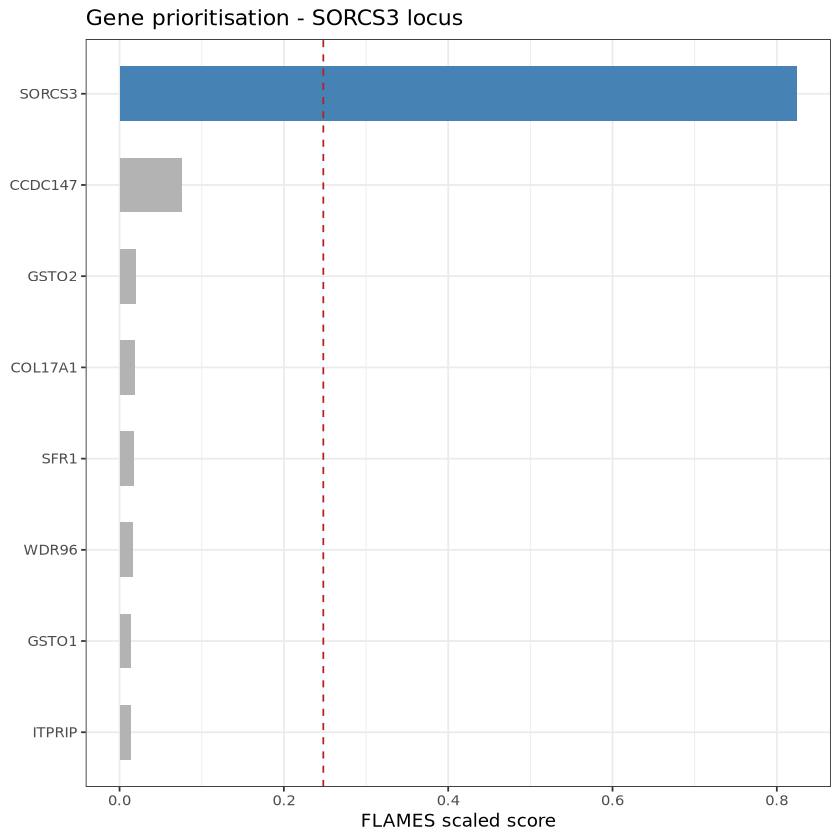

In [7]:
# Bar chart of scaled scores with the threshold line.
ggplot(scores, aes(x = reorder(symbol, FLAMES_scaled), y = FLAMES_scaled)) +   # y = scaled score
  geom_col(aes(fill = FLAMES_scaled >= threshold), width = 0.6) +
  geom_hline(yintercept = threshold, linetype = "dashed", colour = "firebrick") +
  scale_fill_manual(values = c(`FALSE` = "grey70", `TRUE` = "steelblue"), guide = "none") +
  coord_flip() +
  labs(x = NULL, y = "FLAMES scaled score", title = "Gene prioritisation - SORCS3 locus") +
  theme_bw()

::: callout-note
**Question.** One gene satisfies the threshold. Which
gene is it, and what is its estimated precision? Does the ranking agree with what
you would have guessed from the locus name alone?
:::

## 3: XGBoost and PoPS scores

The **XGBoost** score is used as the SNP-to-gene
evidence. The **PoPS** score is rescaled within the locus to between 0.292 and 1 and
multiplied into it, so weak convergence pulls a gene down. The gene with the highest
PoPS in the locus is scaled up further, by 0.583. In the paper: "XGBoost scores are
multiplied with scaled PoPS, so that XGBoost scores are decreased for genes with
lower PoPS."

So a gene with no SNP-to-gene evidence scores zero however strong its PoPS. The
`.raw` table keeps both scores.

    symbol  XGB_score  PoPS_Score rel_XGB_score rel_PoPS_Score  FLAMES_raw
    <char>      <num>       <num>         <num>          <num>       <num>
1:  SORCS3 0.25660000  1.08451751    1.00000000      1.0000000 0.406197786
2: CCDC147 0.09661511 -0.11997761    0.37652034      0.3848473 0.037182063
3:   GSTO2 0.02843991 -0.21327426    0.11083361      0.3371994 0.009589918
4: COL17A1 0.02280814 -0.09361396    0.08888597      0.3983116 0.009084746
5:    SFR1 0.02298300 -0.14453327    0.08956741      0.3723064 0.008556715
6:   WDR96 0.02298300 -0.17405298    0.08956741      0.3572302 0.008210221
7:   GSTO1 0.02298300 -0.26895326    0.08956741      0.3087633 0.007096306
8:  ITPRIP 0.02298300 -0.30177652    0.08956741      0.2920000 0.006711035


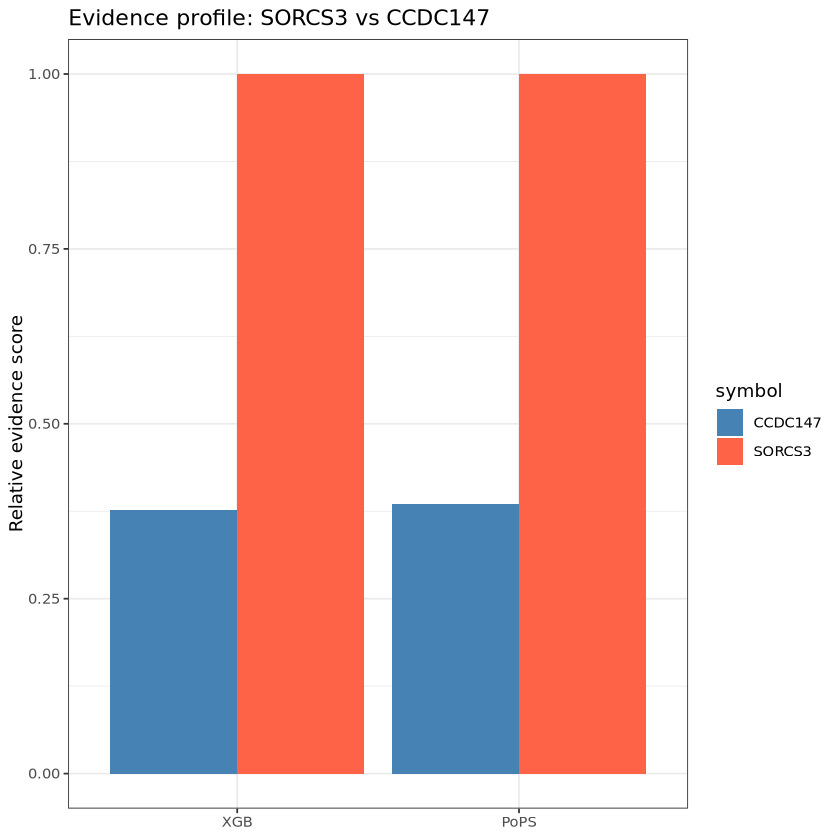

In [8]:
# Show XGBoost and Pops scores for every gene, ranked by the final score.
print(scores[order(-FLAMES_scaled),
             .(symbol, XGB_score, PoPS_Score, rel_XGB_score, rel_PoPS_Score, FLAMES_raw)])

# Compare the top gene's evidence profile against its closest competitor.
top_gene  <- scores[which.max(FLAMES_scaled), symbol]
runner_up <- scores[order(-FLAMES_scaled)][2, symbol]

prof <- melt(scores[symbol %in% c(top_gene, runner_up),
                    .(symbol, XGB = rel_XGB_score, PoPS = rel_PoPS_Score)],
             id.vars = "symbol", variable.name = "Evidence", value.name = "Score")

ggplot(prof, aes(x = Evidence, y = Score, fill = symbol)) +
  geom_col(position = "dodge") +
  scale_fill_manual(values = c("steelblue", "tomato")) +
  labs(title = paste("Evidence profile:", top_gene, "vs", runner_up),
       y = "Relative evidence score", x = NULL) +
  theme_bw()

::: callout-note
**Question.** For the top gene, do **both** XGBoost and PoPS support it,
or just one? Why does agreement between two independent kinds of evidence make a
call more trustworthy than a high score from just one?
:::

::: callout-tip
**Reporting** "FLAMES prioritised *SORCS3* (scaled 0.82, est. precision
0.95), supported by both the functional V2G ensemble and the PoPS gene score; the
nearest competitor scored below the 0.248 reporting threshold." State the score,
the precision, and *which* evidence agreed.
:::

## 4: What a confident call means

For SORCS3 the lead variant rs11596214 is **intronic in SORCS3 itself**, and
in the ADHD paper SORCS3 is nominated on both common- and rare-variant evidence,
so here FLAMES, proximity, and the original study all agree. It's not always the case.

::: callout-note
**A locus where the SNP-to-gene evidence pointed at the wrong gene: FSHB / ARL14EP.**

The worked example in the FLAMES paper is a GWAS of being the mother of dizygotic
twins. At one locus, most of the SNP-to-gene evidence points to *ARL14EP*: the
significant variants sit inside its gene body, and the XGBoost score is highest for
it. *FSHB*, the beta subunit of follicle-stimulating hormone, is only a close second
on that evidence.

The convergence score changes that. In the paper: "Although the XGB model
assigns a high score to ARL14EP, FSHB is a close second in the locus. Combined with
the convergence-based score, FSHB receives a higher FLAMES score than ARL14EP,
prioritizing FSHB when applying the recommended threshold." They note the FSHB call
"is in line with the expected underlying biology of the trait".

SORCS3 locus goes the other way. rs11596214 sits inside SORCS3, and SORCS3 is what
FLAMES returns. At the twinning locus the variants also sit inside a gene, and that
gene loses. Being the gene the variant sits in helps, but it does not settle it.

Neither stream gets the twinning locus right on its own, which is why FLAMES uses
two. In the same GWAS it also picked *GNRH1*, which you would miss by taking the
closest gene with the highest PoPS.
:::

::: callout-warning
**Three things to keep in mind.**

- **Wrong-tissue eQTL**: colocalisation in an irrelevant tissue can promote the
  wrong gene. FLAMES is only as good as the annotation panels behind it.
- **Nearest-gene bias**: when eQTL/chromatin evidence is thin, distance
  dominates. Taking the closest gene is a real competitor, not a straw man. In the
  FLAMES benchmarks it reaches F1 0.50 to 0.62, and closest gene plus highest PoPS
  is 3.1% *more* precise than FLAMES. What FLAMES buys is recall, about 33.2% more
  correctly identified causal genes. SORCS3 happens to be both nearest and
  prioritised, which is luck, not a rule.
- **Above-threshold is not causal**: ~75% precision at the threshold means about 1 in 4
  top calls is wrong. FLAMES prioritises, it does not prove causality.
:::

::: callout-note
**Credible sets are the basis for flames**

FLAMES annotates whatever credible set you give it. If that set is wrong, every
annotation built from it is wrong, and nothing downstream will tell you. "We urge potential users to be careful when using fine-mapping
output created by using out-of-sample reference panels, as these can generate
spurious fine-mapping results, which could impact the annotation scores generated
by FLAMES." And: "Better fine-mapping will lead to better predictions."

:::

::: callout-note
**Question.** What independent evidence would raise your confidence that SORCS3
(not a neighbour) is the true effector, for example a colocalising brain eQTL, the
rare-variant burden signal from the paper, or a functional/CRISPR perturbation?
:::

### Final effector-gene table

In [9]:
# Build and save the final table: locus, gene, scaled score, precision, tier.
final_table <- scores[, .(
  Locus      = locus,
  Gene       = symbol,
  FLAMES     = round(FLAMES_scaled, 3),
  Precision  = round(estimated_cumulative_precision, 3),
  Confidence = fcase(
    FLAMES_scaled >= 0.248, "reported (~75% precision)",
    FLAMES_raw    >  0.134, "suggestive (clears raw gate only)",
    default                = "below threshold")
)][order(-FLAMES)]

print(final_table)
fwrite(final_table, "output/fm_out/effector_genes_final.tsv", sep = "\t")
cat("Saved to", "output/fm_out/effector_genes_final.tsv", "\n")

   Locus    Gene FLAMES Precision                Confidence
   <int>  <char>  <num>     <num>                    <char>
1:     0  SORCS3  0.825     0.948 reported (~75% precision)
2:     0 CCDC147  0.075     0.000           below threshold
3:     0   GSTO2  0.019     0.000           below threshold
4:     0 COL17A1  0.018     0.000           below threshold
5:     0    SFR1  0.017     0.000           below threshold
6:     0   WDR96  0.017     0.000           below threshold
7:     0   GSTO1  0.014     0.000           below threshold
8:     0  ITPRIP  0.014     0.000           below threshold
Saved to output/fm_out/effector_genes_final.tsv 
